In [86]:
import numpy as np

from scipy.stats import norm, expon
from scipy.io import arff
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from scipy.integrate import trapezoid, cumulative_trapezoid, cumulative_simpson
from sklearn.neighbors import NearestNeighbors

arff_file = arff.loadarff('../real/HeartDisease_withoutdupl_norm_44.arff')
#arff_file = arff.loadarff('./clusters/real-world/iris.arff')
df4 = pd.DataFrame(arff_file[0])

X = df4.drop(columns=['outlier','id']).values
y = df4['outlier'].values
le = LabelEncoder()
y = le.fit_transform(y)

In [87]:
def main(X, y, n):
    nn = NearestNeighbors(n_neighbors=n)
    nn.fit(X, y)
    dist, knn = nn.kneighbors(X)  # returns N index neighbors including self
    return knn, dist


def generateArr(newDist, median='median'):
    arr = []
    for x in newDist:  # finds the distance away from that point (index 0)
        if median == 'median':
            arr += [np.median(x)]
        elif median == 'sum':  # min + median + max
            arr += [x[1] + np.max(x) + np.median(x)]
        elif median == 'max':
            arr += [np.max(x)]
        elif median == 'minMax':
            arr += [np.max(x) + x[1]]
        elif median == 'medMax':
            arr += [np.median(x) + np.max(x)]
        elif median == 'min':
            arr += [x[1]]

    return arr

In [88]:
from gaussian_exponential_mixture import GaussianExponentialMixture
#beta, mu, sigma = 1, 10, 1
#exponential_data = np.random.exponential(scale=beta, size=500)
#gaussian_data = np.random.normal(loc=mu, scale=sigma, size=500)
#mixed_data = np.append(exponential_data, gaussian_data)
knn, distReturn = main(X, y, 12)
distReturn = np.array(distReturn)
arr = generateArr(distReturn, median="medMax")
arr = (arr - np.min(arr)) / (np.max(arr) - np.min(arr))
print(arr)
mix = GaussianExponentialMixture(arr)
mix.fit()

[0.66026011 0.78053755 0.38567214 0.20438116 0.71437028 0.29740393
 0.55801981 0.1338486  0.28298042 0.72486459 0.29521284 0.30018949
 0.12838103 0.5948161  0.17523098 0.38625513 0.23806402 0.72190327
 0.70110501 0.65186807 0.17074551 0.25575638 0.28602132 0.14179311
 0.76518746 0.11342148 0.59103943 0.1105958  0.28251355 0.6594874
 0.23997886 0.40993813 0.10743027 0.4777098  0.16159858 0.68881798
 0.2382461  0.42440139 0.05766066 0.19549064 0.36944716 0.2350282
 0.57938895 0.64005114 0.55070015 0.57962783 0.62876556 0.29098516
 0.62594497 0.7213367  0.29717944 0.57789455 0.63712354 0.331107
 0.30509812 0.19370474 0.44506392 0.70619549 0.64379698 0.39703298
 0.58142552 0.63597555 0.03663339 0.33048793 0.7580986  0.1962373
 0.57528119 0.70494533 0.18750071 0.03185359 0.23819481 0.61286561
 0.37916293 0.40871117 0.40116876 0.4081258  0.48773228 0.16797314
 0.14158452 0.07415177 0.35742116 0.34356895 0.30004282 0.23189076
 0.25066322 0.49573841 0.61065122 0.72184056 0.16179839 0.32900127


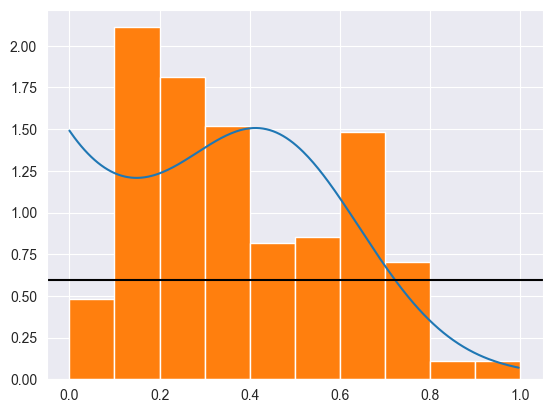

1.451430266757245


In [89]:
from matplotlib import pyplot as plt
x = np.arange(1, step=1/arr.size)
plt.plot(x, mix.pdf(x))
plt.hist(arr, density=True, bins=10)
plt.axhline(y=np.percentile(mix.pdf(arr), 5), color='k')
plt.show()
print(mix.pdf(.34))

In [90]:
print(mix.pdf(x))
print(mix.pdf(arr))
data = mix.pdf(x)
norm = (data-np.min(data))/(np.max(data)-np.min(data))
data2 = mix.pdf(arr)
dataNorm = (data-np.min(data2))/(np.max(data2)-np.min(data2))
print(cumulative_trapezoid(mix.pdf(x),x=x))

[1.49147236 1.47712098 1.46315275 1.44956713 1.43636358 1.42354159
 1.4111006  1.3990401  1.38735953 1.37605833 1.36513592 1.35459167
 1.34442493 1.334635   1.32522113 1.31618252 1.30751831 1.29922755
 1.29130923 1.28376225 1.27658543 1.26977749 1.26333702 1.25726254
 1.25155242 1.24620493 1.24121818 1.23659018 1.23231876 1.22840162
 1.22483629 1.22162015 1.21875041 1.21622409 1.21403805 1.21218894
 1.21067325 1.20948723 1.20862698 1.20808836 1.20786702 1.20795842
 1.20835778 1.20906011 1.2100602  1.2113526  1.21293165 1.21479145
 1.21692586 1.21932853 1.22199286 1.22491203 1.22807897 1.23148639
 1.23512678 1.23899237 1.2430752  1.24736706 1.25185954 1.25654399
 1.26141156 1.26645319 1.27165963 1.27702141 1.28252889 1.28817223
 1.29394141 1.29982627 1.30581645 1.31190145 1.31807065 1.32431326
 1.3306184  1.33697503 1.34337206 1.34979827 1.35624237 1.36269301
 1.36913877 1.37556819 1.38196978 1.38833204 1.39464345 1.4008925
 1.40706773 1.41315767 1.41915095 1.42503622 1.43080224 1.43643

In [91]:
arrNew = (arr - np.min(arr)) / (np.max(arr) - np.min(arr))

0.9442568044826434
[1 1 1]


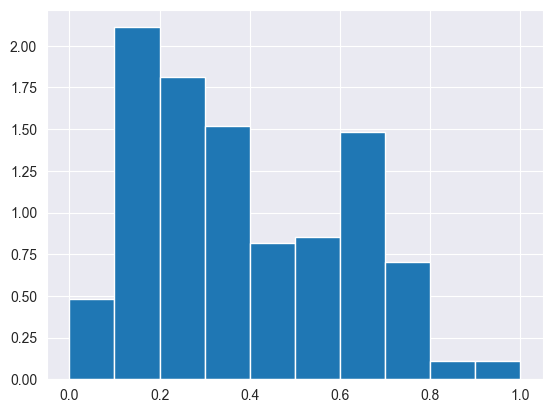

In [113]:
print(np.percentile(cumulative_trapezoid(mix.pdf(x),x=x),80))
print(y[arrNew > .94])
plt.hist(arrNew,density=True, bins=10)
plt.show()